In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
MODEL_PATH = "../models/resnet50_adam.h5"

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False)

print("Model loaded successfully")

Model loaded successfully


In [4]:
TEST_DIR = "../data/test"

test_images = os.listdir(TEST_DIR)

print(len(test_images))
print(test_images[:5])

175
['vid_5_25100.jpg', 'vid_5_25120.jpg', 'vid_5_25140.jpg', 'vid_5_25160.jpg', 'vid_5_25180.jpg']


In [5]:
IMG_SIZE = 224

def predict_image(image_path):
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w, _ = img.shape
    
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0
    
    input_img = np.expand_dims(normalized, axis=0)
    
    prediction = model.predict(input_img)[0]
    
    xmin = int(prediction[0] * w)
    ymin = int(prediction[1] * h)
    xmax = int(prediction[2] * w)
    ymax = int(prediction[3] * h)
    
    return img, (xmin, ymin, xmax, ymax)

In [7]:
def visualize_prediction(image_path):
    
    img, (xmin, ymin, xmax, ymax) = predict_image(image_path)
    
    cv2.rectangle(
        img,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )
    
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


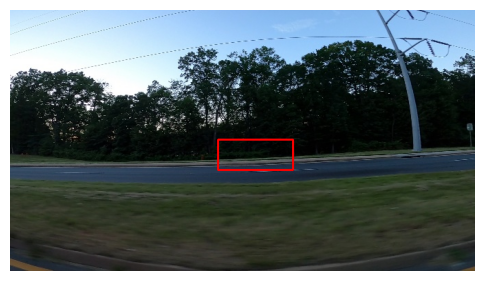

In [8]:
sample = os.path.join(TEST_DIR, test_images[0])

visualize_prediction(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


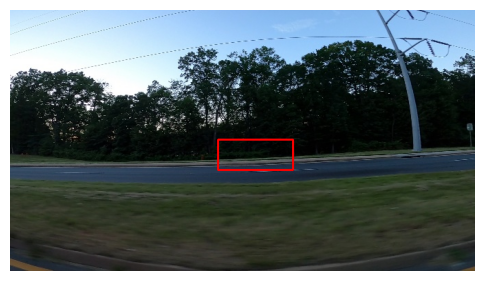

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


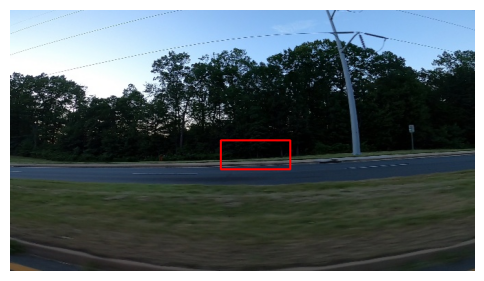

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


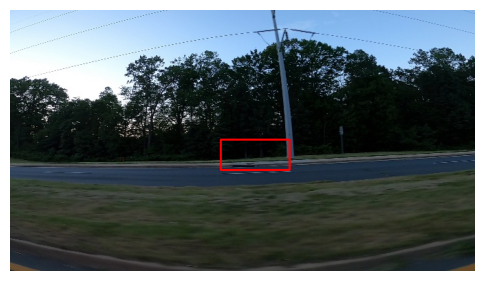

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


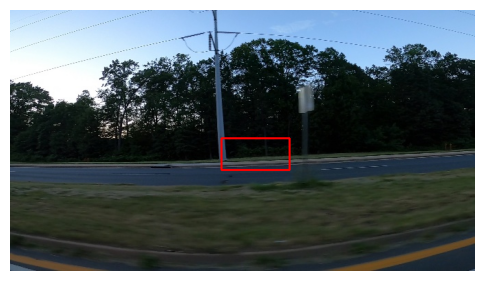

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


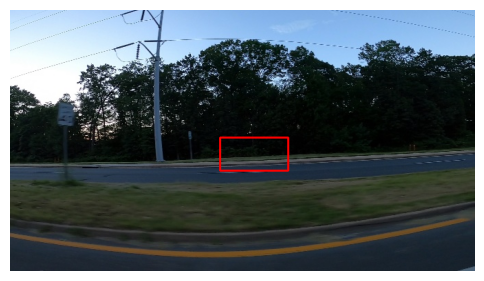

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


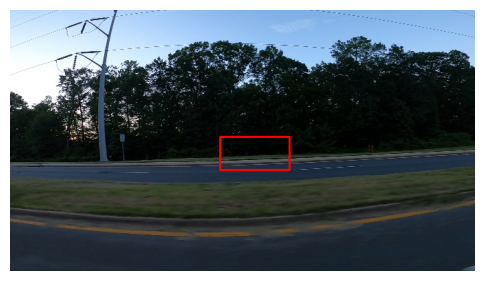

In [9]:
for i in range(6):
    
    sample = os.path.join(TEST_DIR, test_images[i])
    visualize_prediction(sample)

In [10]:
OUTPUT_DIR = "../evaluation/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
def save_prediction(image_path, save_path):
    
    img, (xmin, ymin, xmax, ymax) = predict_image(image_path)
    
    cv2.rectangle(
        img,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )
    
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    cv2.imwrite(save_path, img)

In [12]:
for i in range(10):
    
    img_name = test_images[i]
    
    image_path = os.path.join(TEST_DIR, img_name)
    save_path = os.path.join(OUTPUT_DIR, img_name)
    
    save_prediction(image_path, save_path)

print("Saved predictions successfully")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Saved predictions successfully
